In [1]:
from scipy.io import loadmat
import numpy as np

import snntorch.spikeplot as splt
from snntorch import functional as SF

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, TensorDataset, WeightedRandomSampler

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
subATrain_mat = loadmat('C:/Users/crims/Desktop/Senior Design Code/datasets/BCI_Comp_III_Wads_2004/Subject_A_Train.mat')
print(subATrain_mat.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Signal', 'TargetChar', 'Flashing', 'StimulusCode', 'StimulusType'])


In [3]:
subA_Signal = torch.from_numpy(subATrain_mat['Signal'])
print(subA_Signal.shape)

subA_Flashing = torch.from_numpy(subATrain_mat['Flashing'].astype(int))
print(subA_Flashing.shape)

subA_StimulusType = torch.from_numpy(subATrain_mat['StimulusType'].astype(int))
print(subA_StimulusType.shape)

torch.Size([85, 7794, 64])
torch.Size([85, 7794])
torch.Size([85, 7794])


In [4]:
x = torch.zeros(85*15*12, 144, 64)
y = torch.zeros(85*15*12, dtype=int)
count = 0
# for each character epoch
for e in range(subA_Signal.size(0)):
    # going through all sample collections
    for s in range(1, subA_Signal.size(1)):
        # when flashing turns from on to off
        if subA_Flashing[e, s] == 0 and subA_Flashing[e, s-1] == 1:
            # puts into x the 600ms window for that response
            x[count, :, :] = subA_Signal[e, s:s+144, :]
            # marks true output as 1 if P300 and 0 if not
            if subA_StimulusType[e, s-1] == 1:
                y[count] = 1
            else:
                y[count] = 0
            count+= 1

In [5]:
print(x.shape)
print(y.size())
print(x[0, :, 6])
print(count)
print(y[0:12])

torch.Size([15300, 144, 64])
torch.Size([15300])
tensor([  2.4625,   1.4391,   0.4157,   5.7884,   4.2533,  -1.1193,   0.1599,
         14.7428,  10.9052,  -8.0270,  -1.1193,   8.3468,   7.5793,   3.4858,
         -2.9102,  -0.6076,   3.7417,   7.5793,   7.0676,   4.5092,   7.8351,
         10.1377,   6.0442,  -1.1193,   0.4157,   1.4391,   2.4625,   7.0676,
         13.7194,  14.4869,  15.5103,   5.0209,  -0.3518,   7.5793,  12.1844,
          9.3701,  -0.8635,  -3.4219,   8.3468,  16.5337,   5.7884,   2.7183,
          7.3234,  10.9052,  14.4869,  16.0220,  11.1610,  13.9753,  26.2556,
         16.7895,   0.6716,  -1.1193,   0.4157,   5.2767,  12.6961,  14.4869,
          5.2767,   2.7183,   8.3468,   3.7417,  -2.3985,  -2.3985,   2.9741,
          7.0676,   7.3234,   4.2533,   0.9274,   3.7417,   9.6260,   5.2767,
         -3.4219,  -1.1193,   5.0209,   3.4858,  -1.8868,  -0.0959,   1.1833,
         -2.6543,  -6.2361,  -5.9803,  -3.9335,  -0.3518,   7.5793,   4.7650,
         -2.142

In [6]:
x = x.unsqueeze(1)
print(x.shape)
x = x.repeat(1, 15, 1, 1)
print(x.shape)

torch.Size([15300, 1, 144, 64])
torch.Size([15300, 15, 144, 64])


In [7]:
# separate dataset into training, validation, and testing
full_dataset = TensorDataset(x, y)
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

total_size = len(full_dataset)
train_size = int(train_ratio * total_size)
val_size = int(val_ratio * total_size)
test_size = total_size - train_size - val_size

lengths = [train_size, val_size, test_size]
print(f"Train size: {train_size}, Val size: {val_size}, Test size: {test_size}")

torch.manual_seed(42) 
train_dataset, val_dataset, test_dataset = random_split(full_dataset, lengths)


Train size: 10710, Val size: 2295, Test size: 2295


In [8]:
train_indices = train_dataset.indices
train_labels = y[train_indices]
class_counts = np.bincount(train_labels)
print(class_counts)
# Calculate inverse frequencies
class_weights = 1. / class_counts
print(class_weights)
# Assign weight to each sample based on its class
sample_weights = class_weights[train_labels]
print(sample_weights)

sampler = WeightedRandomSampler(
    sample_weights, 
    len(sample_weights), 
    replacement=True # Allows oversampling of minority classes
)

# Normalize weights (optional, but often helpful)
class_weights = class_weights / class_weights.sum() * len(class_counts) 

print(class_weights)
# Convert to a PyTorch tensor
weights_tensor = torch.tensor(class_weights, dtype=torch.float)

[8949 1761]
[0.00011174 0.00056786]
[0.00011174 0.00011174 0.00011174 ... 0.00011174 0.00011174 0.00011174]
[0.32885154 1.67114846]


In [9]:
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=5, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [10]:
from pipeline_functions import SNNModule, train

model = SNNModule.createSNN(144*64, 316)

lr = 1e-3
num_epochs=5
# criterion = nn.CrossEntropyLoss()
criterion = SF.ce_rate_loss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

history = train.train(model, num_epochs, train_loader, val_loader, criterion, optimizer, device=device, update_every=1, batch_first=True)

Epoch 0: Training Loss: 0.691043733526456, Training Accuracy: 0.6002801120448179, 
Epoch 1: Training Loss: 0.6838685112061843, Training Accuracy: 0.61531279178338, 
Epoch 2: Training Loss: 0.6772977935388531, Training Accuracy: 0.6256769374416433, 
Epoch 3: Training Loss: 0.6680504079515082, Training Accuracy: 0.6364145658263305, 
Epoch 4: Training Loss: 0.6608688129096472, Training Accuracy: 0.6458450046685341, 


In [11]:
data, targets = next(iter(val_loader))
print(data.shape)
data, targets = data.to(device), targets.to(device)
with torch.no_grad():
    model.eval()
    spk_rec, mem_rec = model(data, batch_first=True)

spk_rec = spk_rec[:, 4, :]
mem_rec = mem_rec[:, 4, :]
print(mem_rec)
print(spk_rec)
print(mem_rec.shape)
print(spk_rec.shape)

torch.Size([5, 15, 144, 64])
tensor([[0.3958, 0.4795],
        [0.7520, 0.9111],
        [1.0725, 1.2994],
        [0.3610, 0.6490],
        [0.7207, 1.0636],
        [1.0444, 0.4367],
        [0.3357, 0.8726],
        [0.6979, 1.2648],
        [1.0239, 0.6178],
        [0.3173, 1.0355],
        [0.6813, 0.4115],
        [1.0090, 0.8498],
        [0.3038, 1.2444],
        [0.6692, 0.5994],
        [0.9981, 1.0190]])
tensor([[0., 0.],
        [0., 0.],
        [1., 1.],
        [0., 0.],
        [0., 1.],
        [1., 0.],
        [0., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [0., 0.],
        [1., 0.],
        [0., 1.],
        [0., 0.],
        [0., 1.]])
torch.Size([15, 2])
torch.Size([15, 2])


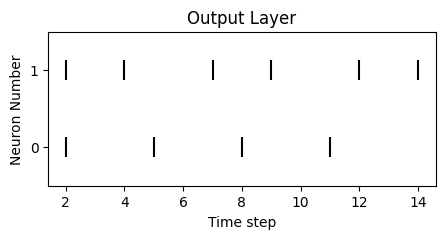

In [38]:
fig = plt.figure(facecolor="w", figsize=(5, 2))
ax = fig.add_subplot(111)

#  s: size of scatter points; c: color of scatter points
splt.raster(spk_rec, ax, s=200, c="black", marker='|')
plt.yticks([0, 1], ['0', '1'])
ax.set_ylim(-0.5, 1.5)
plt.title("Output Layer")
plt.xlabel("Time step")
plt.ylabel("Neuron Number")
plt.show()

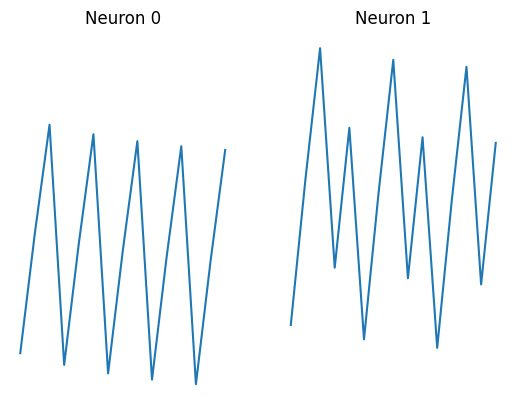

In [35]:
splt.traces(mem_rec, dim=(1, 2), titles=['Neuron 0', 'Neuron 1'])